In [44]:
import re
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [45]:
import os
os.chdir('/Volumes/SSD/climate-risk')

# Load only the columns we need — avoids materialising the full 2.38 GB file
df = duckdb.sql("""
    SELECT gis_pin, mod_iv_year, building_description
    FROM read_parquet('data/parcels_shore.parquet')
""").df()

print(f"{len(df):,} rows | {df['building_description'].isna().sum():,} null ({df['building_description'].isna().mean():.1%})")
print(f"{df['building_description'].nunique():,} unique values")

6,779,800 rows | 305,024 null (4.5%)
103,075 unique values


In [46]:
# Top 50 values across all years
top = df['building_description'].value_counts().head(50)
print(top.to_string())

building_description
1SF                288151
2SF                239138
1S-F               125498
1SF1G              120313
2S-F               112633
CONDO               71850
2SF1G               65546
2SF2G               52556
1SF2G               46382
1S-F-R              44865
1.5SF               41721
1SF1G      1232     40455
2SF-COLONIAL        39690
CONDO UNIT          37933
1S-F-F              36173
1SF-RANCH           31601
1.5S-F              26608
2S-F-AG             26541
1S-F,1ST FL         24703
1S-F,2ND FL         24504
COMMON ELEMENTS     23438
1SF1G      1124     22899
B2S                 22727
CONDOMINIUM         22068
F2S                 20937
1S-F-AG             19232
1SF1G      1328     18332
3S-F                18281
1.5SF1G             18223
3S-FR               17395
1S-F-1G             15993
1SF1G      1440     15757
2S-AL-O-1U          14610
2S-AL-L-AG-1U       14462
2SF-2AG             13657
F1S                 13139
1S-F-R-1AG          12795
2S-AL-L-1U       

In [47]:
# ── lookup tables  (NJ MOD-IV Reference F — official codes) ───────────────────
# Field order: stories → structure/material → style → num stalls → garage type

MATERIAL_MAP = {
    # 2-char codes (always try before 1-char to avoid prefix collisions)
    'AL': 'aluminum',           # aluminum siding
    'CB': 'concrete_block',
    'RC': 'reinforced_concrete',
    'SS': 'structured_steel',
    'ST': 'stone',
    'SB': 'small_bldg',        # non-standard but appears in data
    # 1-char codes
    'B':  'brick',
    'F':  'frame',
    'M':  'metal',
    'S':  'stucco',
    'W':  'wood',
}

# Full-word material names used by assessors who pre-decoded the field
MATERIAL_TEXT_MAP = {
    'FRAME':      'frame',
    'BRICK':      'brick',
    'WOOD':       'wood',
    'STONE':      'stone',
    'METAL':      'metal',
    'STUCCO':     'stucco',
    'ALUMINUM':   'aluminum',
    'CONCRETE':   'concrete_block',
}

STYLE_MAP = {
    # official single-char codes
    'A': 'commercial',
    'B': 'industrial',
    'C': 'apartments',
    'D': 'dutch_colonial',
    'E': 'english_tudor',
    'L': 'colonial',
    'M': 'mobile_home',
    'R': 'rancher',
    'S': 'split_level',
    'T': 'twin',
    'W': 'row_home',
    'X': 'duplex',
    'Z': 'raised_rancher',
    'O': 'other',
    '2': 'bi_level',
    '3': 'tri_level',
    # text variants (pre-decoded or verbose assessor entries)
    'RANCH':      'rancher',
    'RANCHER':    'rancher',
    'COLONIAL':   'colonial',
    'CAPE':       'cape',
    'BILEVEL':    'bi_level',
    'TRILEVEL':   'tri_level',
    'SPLIT':      'split_level',
    'TWIN':       'twin',
    'DUPLEX':     'duplex',
    'COMMERCIAL': 'commercial',
    'INDUSTRIAL': 'industrial',
    'APARTMENTS': 'apartments',
    'TOWNHOUSE':  'townhouse',
    'TOWNHOME':   'townhouse',
    'BUNGALOW':   'bungalow',
    'GAMBREL':    'gambrel',
}

# Subset for full-word token matching (skip single-char codes; those go through _compact_suffix)
STYLE_TEXT_MAP = {k: v for k, v in STYLE_MAP.items() if len(k) > 1}

GARAGE_TYPE_MAP = {
    # official
    'AG':  'attached',
    'UG':  'unattached',   # NJ manual: UG = Unattached Garage
    # extensions found in this dataset
    'BIG': 'basement_integral',
    'DG':  'detached',
    'OB':  'outbuilding',
    'CP':  'carport',
    'G':   'generic',
}

# ── compiled patterns ─────────────────────────────────────────────────────────
_MAT_2 = {'AL', 'CB', 'RC', 'SS', 'ST', 'SB'}
_MAT_1 = {'B', 'F', 'M', 'S', 'W'}
_STYLE_CHARS = set('ABCDELMRSTVWXZO') | {'2', '3'}

_mat_pat = '|'.join(sorted(MATERIAL_MAP,    key=len, reverse=True))
_gar_pat = '|'.join(sorted(GARAGE_TYPE_MAP, key=len, reverse=True))

_AREA_CODE    = re.compile(r'\s+\d{3,4}$')
_FLOOR        = re.compile(r'\b(\d+)(?:ST|ND|RD|TH)\s*FL\b')
_STORIES      = re.compile(r'^(\d+\.?\d*)(SB|S|F|)')
_N_STORY      = re.compile(r'\b(\d+)\s*STOR(?:Y|IES)\b')   # "2 STORY", "3 STORIES"
_REVERSED     = re.compile(r'^(' + _mat_pat + r')(\d+\.?\d*)[SF]?$')
_REVERSED_GAR = re.compile(r'^([A-Z]{1,2})(\d+\.?\d*)\s+([A-Z]{1,3})(\d?)$')
_GARAGE       = re.compile(r'^(\d?)(' + _gar_pat + r')$')
_GARAGE_REV   = re.compile(r'^(' + _gar_pat + r')(\d)$')   # reversed: type+stalls e.g. "G2"
_UNIT_SFX     = re.compile(r'^\d+U$')
_PLAN_NAME_RE = re.compile(r'^[A-Z][A-Z\s\.\-]+$')  # all-alpha, no digit prefix

_SKIP = {'COND', 'CONDO', 'CONDOMINIUM', 'UNIT', 'COMMON', 'ELEMENT', 'ELEMENTS',
         'FL', 'ND', 'RD', 'TH', 'DWELLING', 'BLDG', 'STORY', 'STORIES',
         'DEMO', 'GARAGE', 'SHED', 'SLF'}

# Words that are genuine NJ MOD-IV codes or descriptors — not plan names.
# Includes single-char style/garage codes so "G CYPRESS" (G=known, CYPRESS=unknown)
# is correctly flagged as a model plan rather than parsed as a garage prefix.
_KNOWN_VOCAB = {
    'AL', 'CB', 'RC', 'SS', 'ST', 'SB', 'B', 'F', 'M', 'S', 'W',
    'A', 'C', 'D', 'E', 'L', 'R', 'T', 'X', 'Z', 'O', 'G',
    'ALUMINUM', 'BRICK', 'CONCRETE', 'FRAME', 'METAL', 'STUCCO', 'WOOD', 'STONE', 'SIDING',
    'COLONIAL', 'RANCH', 'RANCHER', 'CAPE', 'BUNGALOW', 'SPLIT', 'TWIN', 'DUPLEX',
    'GAMBREL', 'COMMERCIAL', 'INDUSTRIAL', 'APARTMENTS', 'TOWNHOUSE', 'TOWNHOME',
    'CONDO', 'CONDOMINIUM', 'COMMON', 'DWELLING', 'DOCK', 'GARAGE', 'UNIT',
    'LEVEL', 'STORY', 'STORIES',
}

# ── compact suffix parser ─────────────────────────────────────────────────────
def _compact_suffix(tok, r):
    """Left-to-right positional parse of a compact (no-delimiter) token.

    Only commits parsed values when the ENTIRE token is consumed — prevents
    development plan names (STRATFORD, BARONET, FAIRFAX) from bleeding into
    material/style columns.
    """
    s, n = tok, len(tok)
    i = 0
    tentative = {'bd_material': None, 'bd_style': None,
                 'bd_garage_type': None, 'bd_garage_stalls': None}

    # 1. material — 2-char unambiguous codes first, then 1-char
    if i + 2 <= n and s[i:i+2] in _MAT_2:
        tentative['bd_material'] = MATERIAL_MAP[s[i:i+2]]
        i += 2
    elif i < n and s[i] in _MAT_1:
        # Only consume as material when it isn't already set.
        # If set, leave i so the style step can claim this char (e.g. 'S' → split_level).
        if r['bd_material'] is None and tentative['bd_material'] is None:
            tentative['bd_material'] = MATERIAL_MAP[s[i]]
            i += 1

    # 2. style — skip if the remaining string is itself a complete garage token
    if i < n:
        rest = s[i:]
        at_garage = bool(
            _GARAGE.match(rest) or
            (rest[0].isdigit() and len(rest) > 1 and _GARAGE.match(rest[1:]))
        )
        if not at_garage and s[i] in _STYLE_CHARS:
            tentative['bd_style'] = STYLE_MAP.get(s[i])
            i += 1

    # 3. garage: [num_stalls][type]
    if i < n:
        gm = _GARAGE.match(s[i:])
        if gm:
            stalls_s, gt = gm.group(1), gm.group(2)
            tentative['bd_garage_type']   = GARAGE_TYPE_MAP[gt]
            tentative['bd_garage_stalls'] = int(stalls_s) if stalls_s else 0
            i += len(gm.group(0))

    # Commit only when the full token was consumed — rejects partial plan-name parses
    if i != n:
        return
    for k, v in tentative.items():
        if v is not None and r[k] is None:
            r[k] = v


# ── main parser ───────────────────────────────────────────────────────────────
def _empty():
    return dict(
        bd_stories=None, bd_material=None, bd_style=None,
        bd_garage_stalls=None, bd_garage_type=None,
        bd_is_condo=False, bd_is_common_element=False,
        bd_unit_floor=None, bd_is_model_plan=False,
    )

def parse_building_desc(raw):
    r = _empty()
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return r
    # strip surrounding quotes (some assessors wrap codes in quotes, e.g. "B")
    s = str(raw).strip().strip('"\'').strip().upper()
    if not s:
        return r

    # strip trailing area / square-footage code (e.g. "1SF1G      1232")
    s = _AREA_CODE.sub('', s).strip()

    # ── boolean flags ──────────────────────────────────────────────────────────
    if 'COMMON ELEMENT' in s:
        r['bd_is_common_element'] = True
        return r

    if 'CONDO' in s or 'CONDOMINIUM' in s or re.search(r'\bCOND\b', s):
        r['bd_is_condo'] = True

    # dock / pier / bulkhead property — match anywhere in string
    if re.search(r'\bDOCK\b', s) or 'BKHD' in s:
        r['bd_style'] = 'dock'
        return r

    # ── unit floor indicator ───────────────────────────────────────────────────
    fm = _FLOOR.search(s)
    if fm:
        n_fl = int(fm.group(1))
        sfx  = {1: '1st', 2: '2nd', 3: '3rd'}.get(n_fl, f'{n_fl}th')
        r['bd_unit_floor'] = sfx + '_fl'
        s = _FLOOR.sub('', s).strip()

    # ── multi-word text normalisation ──────────────────────────────────────────
    # "2 STORY" / "3 STORIES" → "2S" / "3S"
    s = _N_STORY.sub(lambda m: f'{m.group(1)}S', s)

    for phrase, repl in (('TWO STORY', '2S'), ('THREE STORY', '3S'),
                          ('ONE STORY', '1S'), ('FOUR STORY', '4S')):
        s = s.replace(phrase, repl)

    # multi-word material / style phrases (order matters: longer phrases first)
    for phrase, key, val in (
        ('REINFORCED CONCRETE', 'bd_material', 'reinforced_concrete'),
        ('CONCRETE BLOCK',      'bd_material', 'concrete_block'),
        ('STRUCTURED STEEL',    'bd_material', 'structured_steel'),
        ('ALUMINUM SIDING',     'bd_material', 'aluminum'),
        ('DUTCH COLONIAL',      'bd_style',    'dutch_colonial'),
        ('RAISED RANCHER',      'bd_style',    'raised_rancher'),
        ('MOBILE HOME',         'bd_style',    'mobile_home'),
        ('SPLIT LEVEL',         'bd_style',    'split_level'),
        ('SPLIT-LEVEL',         'bd_style',    'split_level'),
        ('CAPE COD',            'bd_style',    'cape'),
        ('ROW HOUSE',           'bd_style',    'row_home'),
        ('ROW HOME',            'bd_style',    'row_home'),
        ('TRI-LEVEL',           'bd_style',    'tri_level'),
        ('TRI LEVEL',           'bd_style',    'tri_level'),
        ('TRILEVEL',            'bd_style',    'tri_level'),
        ('BI-LEVEL',            'bd_style',    'bi_level'),
        ('BI LEVEL',            'bd_style',    'bi_level'),
        ('BILEVEL',             'bd_style',    'bi_level'),
        ('TOWNHOUSE',           'bd_style',    'townhouse'),
        ('TOWNHOME',            'bd_style',    'townhouse'),
    ):
        if phrase in s:
            if r[key] is None:
                r[key] = val
            s = s.replace(phrase, '').strip()

    if not s:
        return r

    # ── development plan name detection ───────────────────────────────────────
    # Plan names (FAIRFAX, YARDLEY, STRATFORD, ST TROPEZ, RITZ, G CYPRESS …) are
    # all-alpha strings with no digit prefix. Detect and flag rather than misparse.
    # Threshold len >= 4 catches short names (RITZ, ETON, ROXY).
    # Single-char codes in _KNOWN_VOCAB ensure "G CYPRESS" triggers the flag
    # (G is known, CYPRESS is not → not all words in vocab).
    if _PLAN_NAME_RE.match(s):
        words = s.split()
        first_word = words[0]
        if (len(s) >= 4
                and len(first_word) >= 1
                and not all(w in _KNOWN_VOCAB for w in words)):
            r['bd_is_model_plan'] = True
            return r

    # ── standalone decoded names (whole string is one material or style name) ──
    s_alpha = re.sub(r'[^A-Z]', '', s)
    if s_alpha in STYLE_TEXT_MAP and r['bd_style'] is None:
        r['bd_style'] = STYLE_TEXT_MAP[s_alpha]
        return r
    if s_alpha in MATERIAL_TEXT_MAP and r['bd_material'] is None:
        r['bd_material'] = MATERIAL_TEXT_MAP[s_alpha]
        return r

    # ── "F2 G1" pattern: [material][stories] space [garage_type][stalls] ──────
    rv_g = _REVERSED_GAR.match(s)
    if rv_g:
        mat, sto, gar, stalls = rv_g.groups()
        if mat in MATERIAL_MAP and GARAGE_TYPE_MAP.get(gar):
            if r['bd_material'] is None:
                r['bd_material'] = MATERIAL_MAP[mat]
            try:
                r['bd_stories'] = float(sto)
            except ValueError:
                pass
            if r['bd_garage_type'] is None:
                r['bd_garage_type']   = GARAGE_TYPE_MAP[gar]
                r['bd_garage_stalls'] = int(stalls) if stalls else 0
            return r

    # ── reversed format: material-first — "B2S", "F2S", "ST3S" ───────────────
    rv = _REVERSED.match(s)
    if rv:
        if r['bd_material'] is None:
            r['bd_material'] = MATERIAL_MAP.get(rv.group(1))
        try:
            r['bd_stories'] = float(rv.group(2))
        except ValueError:
            pass
        return r

    # ── normal format: [stories][S|F][material][style][garage] ────────────────
    sm = _STORIES.match(s)
    if sm:
        try:
            r['bd_stories'] = float(sm.group(1))
        except ValueError:
            pass
        # 'F' or 'SB' in the suffix position encodes material directly
        if sm.group(2) == 'SB' and r['bd_material'] is None:
            r['bd_material'] = 'small_bldg'
        elif sm.group(2) == 'F' and r['bd_material'] is None:
            r['bd_material'] = 'frame'
        remainder = s[sm.end():]
    else:
        remainder = s

    # ── tokenise by delimiters and parse each token ────────────────────────────
    tokens = [t for t in re.split(r'[-,;.\s]+', remainder) if t]
    for tok in tokens:
        if tok in _SKIP or _UNIT_SFX.match(tok) or tok.isdigit():
            continue

        # story token in the token loop: handles "1S", "2S", and also compact
        # forms like "2SF", "2SL2AG" where the code follows the separator.
        # Requires explicit S/F/SB separator so "2AG" (2-car garage) isn't mistaken.
        sm2 = _STORIES.match(tok)
        if sm2 and sm2.group(1) and sm2.group(2) in ('S', 'F', 'SB') and r['bd_stories'] is None:
            r['bd_stories'] = float(sm2.group(1))
            if sm2.group(2) == 'SB' and r['bd_material'] is None:
                r['bd_material'] = 'small_bldg'
            elif sm2.group(2) == 'F' and r['bd_material'] is None:
                r['bd_material'] = 'frame'
            tok_rem = tok[sm2.end():]
            if tok_rem:
                _compact_suffix(tok_rem, r)
            continue

        # reversed garage token: "G2", "G1", "AG2" (type then stalls)
        grm = _GARAGE_REV.match(tok)
        if grm and r['bd_garage_type'] is None:
            r['bd_garage_type']   = GARAGE_TYPE_MAP[grm.group(1)]
            r['bd_garage_stalls'] = int(grm.group(2))
            continue

        # standard garage match: "AG", "1AG", "2UG"
        gm = _GARAGE.match(tok)
        if gm and r['bd_garage_type'] is None:
            stalls_s, gt = gm.group(1), gm.group(2)
            r['bd_garage_type']   = GARAGE_TYPE_MAP[gt]
            r['bd_garage_stalls'] = int(stalls_s) if stalls_s else 0
            continue

        # full-word decoded material: FRAME, BRICK, WOOD, STONE, …
        if tok in MATERIAL_TEXT_MAP and r['bd_material'] is None:
            r['bd_material'] = MATERIAL_TEXT_MAP[tok]
            continue

        # full-word decoded style: RANCH, COLONIAL, CAPE, TOWNHOUSE, BUNGALOW, …
        if tok in STYLE_TEXT_MAP and r['bd_style'] is None:
            r['bd_style'] = STYLE_TEXT_MAP[tok]
            continue

        # compact positional parse (material → style → garage)
        _compact_suffix(tok, r)

    return r


# ── smoke tests ───────────────────────────────────────────────────────────────
_cases = [
    # basic compact
    ('1SF',             dict(bd_stories=1.0, bd_material='frame')),
    ('2SF2G',           dict(bd_stories=2.0, bd_material='frame', bd_garage_stalls=2, bd_garage_type='generic')),
    ('1.5SSTL2AG',      dict(bd_stories=1.5, bd_material='stone', bd_style='colonial', bd_garage_stalls=2, bd_garage_type='attached')),
    # dash-separated
    ('1S-F-R-1AG',      dict(bd_stories=1.0, bd_material='frame', bd_style='rancher', bd_garage_stalls=1, bd_garage_type='attached')),
    ('2S-AL-L-AG-1U',   dict(bd_stories=2.0, bd_material='aluminum', bd_style='colonial', bd_garage_type='attached')),
    ('3S-FR',           dict(bd_stories=3.0, bd_material='frame', bd_style='rancher')),
    ('2S-F-S',          dict(bd_stories=2.0, bd_material='frame', bd_style='split_level')),
    ('3S-CB',           dict(bd_stories=3.0, bd_material='concrete_block')),
    ('2S-AL-O-1U',      dict(bd_stories=2.0, bd_material='aluminum', bd_style='other')),
    # reversed format
    ('B2S',             dict(bd_stories=2.0, bd_material='brick')),
    ('F2S',             dict(bd_stories=2.0, bd_material='frame')),
    ('S2S',             dict(bd_stories=2.0, bd_material='stucco')),
    # reversed + garage
    ('F2 G1',           dict(bd_stories=2.0, bd_material='frame', bd_garage_stalls=1, bd_garage_type='generic')),
    # boolean flags
    ('CONDO UNIT',      dict(bd_is_condo=True)),
    ('COND 1120',       dict(bd_is_condo=True)),
    ('COMMON ELEMENTS', dict(bd_is_common_element=True)),
    # floor
    ('1S-F,1ST FL',     dict(bd_stories=1.0, bd_material='frame', bd_unit_floor='1st_fl')),
    # half stories / cape
    ('1.5SF-CAPE',      dict(bd_stories=1.5, bd_material='frame', bd_style='cape')),
    ('2SF-COLONIAL',    dict(bd_stories=2.0, bd_material='frame', bd_style='colonial')),
    ('1SB-CONDO',       dict(bd_stories=1.0, bd_material='small_bldg', bd_is_condo=True)),
    # text story replacements
    ('TWO STORY',       dict(bd_stories=2.0)),
    ('2 STORY FRAME',   dict(bd_stories=2.0, bd_material='frame')),
    # multi-word style phrases
    ('BI LEVEL',        dict(bd_style='bi_level')),
    ('SPLIT LEVEL',     dict(bd_style='split_level')),
    ('CAPE COD',        dict(bd_style='cape')),
    ('MOBILE HOME',     dict(bd_style='mobile_home')),
    # UG = unattached (not underground) per official NJ MOD-IV manual
    ('2S-F-1UG',        dict(bd_stories=2.0, bd_material='frame', bd_garage_stalls=1, bd_garage_type='unattached')),
    # pre-decoded full-word material / style
    ('"B"',             dict(bd_material='brick')),
    ('FRAME',           dict(bd_material='frame')),
    ('BRICK RANCHER',   dict(bd_material='brick', bd_style='rancher')),
    ('TOWNHOUSE',       dict(bd_style='townhouse')),
    ('DOCK',            dict(bd_style='dock')),
    # development plan names — must NOT bleed into material / style columns
    ('STRATFORD 1243',  dict(bd_is_model_plan=True, bd_material=None, bd_style=None)),
    ('FAIRFAX 1714',    dict(bd_is_model_plan=True, bd_material=None, bd_style=None)),
    ('BARONET 1050',    dict(bd_is_model_plan=True, bd_material=None, bd_style=None)),
    ('BRIGHTON',        dict(bd_is_model_plan=True, bd_material=None, bd_style=None)),
    ('LYNNE D 1544',    dict(bd_is_model_plan=True, bd_material=None, bd_style=None)),
    # space-separated story suffix (e.g. "F 1S" = frame, 1 story)
    ('F 1S',            dict(bd_stories=1.0, bd_material='frame')),
    ('F 2S',            dict(bd_stories=2.0, bd_material='frame')),
    ('F G2 2S',         dict(bd_stories=2.0, bd_material='frame', bd_garage_stalls=2, bd_garage_type='generic')),
    ('A-2S-AL-STONE',   dict(bd_stories=2.0, bd_style='commercial', bd_material='aluminum')),
    # hybrid plan-name + code: plan word is ignored, code token is parsed
    ('TIVOLI 2SF 2422',  dict(bd_stories=2.0, bd_material='frame')),
    # short plan names (4-char threshold)
    ('RITZ 1474',       dict(bd_is_model_plan=True, bd_material=None, bd_style=None)),
    ('ETON 0671',       dict(bd_is_model_plan=True, bd_material=None, bd_style=None)),
    ('ROXY 1193',       dict(bd_is_model_plan=True, bd_material=None, bd_style=None)),
    # G-prefixed plan names
    ('G CYPRESS 3081',  dict(bd_is_model_plan=True, bd_material=None, bd_style=None)),
    ('G BISCAYNE 2291', dict(bd_is_model_plan=True, bd_material=None, bd_style=None)),
    # bulkhead/dock variant
    ('BKHD/DOCK',       dict(bd_style='dock')),
]

fails = []
for val, expected in _cases:
    got = parse_building_desc(val)
    for k, v in expected.items():
        if got[k] != v:
            fails.append(f"  FAIL  {val!r:25s}  {k}: expected {v!r}, got {got[k]!r}")

if fails:
    print('\n'.join(fails))
else:
    print(f"All {len(_cases)} smoke tests passed ✓")

All 48 smoke tests passed ✓


In [48]:
# Apply parser to all 6.1M rows (~30–60 s)
parsed = pd.DataFrame(df['building_description'].map(parse_building_desc).tolist())

# Attach to original keys
features = pd.concat([df[['gis_pin', 'mod_iv_year']], parsed], axis=1)

print(f"Output shape: {features.shape}")
features.dtypes

Output shape: (6779800, 11)


gis_pin                  object
mod_iv_year               int64
bd_stories              float64
bd_material              object
bd_style                 object
bd_garage_stalls        float64
bd_garage_type           object
bd_is_condo                bool
bd_is_common_element       bool
bd_unit_floor            object
bd_is_model_plan           bool
dtype: object

Total rows          : 6,779,800
Input null          :   305,024  (4.5%)
bd_stories parsed   : 5,899,865  (87.0%)
bd_material parsed  : 5,315,474  (78.4%)
bd_style parsed     : 1,149,067  (16.9%)
bd_is_condo = True  :   309,704
bd_is_common = True :    23,489
bd_is_model_plan    :   292,503


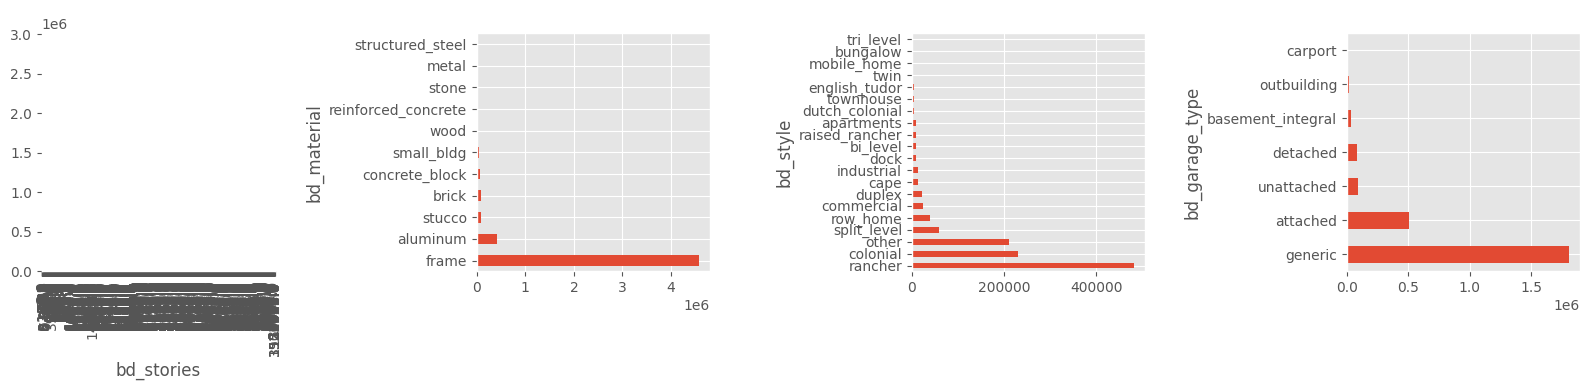


Top truly-unparsed values (no field extracted) — 32,657 rows:
building_description
SLF                1807
GARAGE             1190
.                  1053
ELM                 846
SFD                 630
CON UNIT1.8798%     496
FB2S                478
DANBERRY+           436
F/S2S               432
OAK                 339
F1 1/2              338
F1 1/2 G1           334
N02                 332
G                   326
ELM+                317
NEW S/F HOME        291
CYPRESS/LOFT        288
F/B2S               288
F/B3S               256
CASTLEBURY 3BR      240
CONDUNIT1.8341%     208
G14                 208
B/S2S               208
OCEAN 21   1197     192
CYPRESS+            192
CONDUNIT1.9651%     192
A/2S-AL/PT.2994     180
SF                  180
FG22S               172
P07                 167

Rows missing bd_stories (may still have style/material): 80,280


In [49]:
# ── parse coverage ────────────────────────────────────────────────────────────
n_total      = len(df)
n_input_null = df['building_description'].isna().sum()
n_stories    = features['bd_stories'].notna().sum()
n_material   = features['bd_material'].notna().sum()
n_style      = features['bd_style'].notna().sum()
n_condo      = features['bd_is_condo'].sum()
n_common     = features['bd_is_common_element'].sum()
n_plan       = features['bd_is_model_plan'].sum()

print(f"Total rows          : {n_total:>9,}")
print(f"Input null          : {n_input_null:>9,}  ({n_input_null/n_total:.1%})")
print(f"bd_stories parsed   : {n_stories:>9,}  ({n_stories/n_total:.1%})")
print(f"bd_material parsed  : {n_material:>9,}  ({n_material/n_total:.1%})")
print(f"bd_style parsed     : {n_style:>9,}  ({n_style/n_total:.1%})")
print(f"bd_is_condo = True  : {n_condo:>9,}")
print(f"bd_is_common = True : {n_common:>9,}")
print(f"bd_is_model_plan    : {n_plan:>9,}")

# ── feature distributions ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

features['bd_stories'].value_counts().sort_index().plot.bar(ax=axes[0], title='Stories')
features['bd_material'].value_counts().plot.barh(ax=axes[1], title='Material')
features['bd_style'].value_counts().plot.barh(ax=axes[2], title='Style')
features['bd_garage_type'].value_counts().plot.barh(ax=axes[3], title='Garage type')

plt.tight_layout()
plt.show()

# ── truly unparsed residuals (nothing extracted at all) ───────────────────────
# Separate from "missing stories" — many rows correctly parse style/material
# but have no stories info in the source field (e.g. "COLONIAL", "RANCH", "DOCK").
truly_unparsed_mask = (
    df['building_description'].notna() &
    features['bd_stories'].isna() &
    features['bd_material'].isna() &
    features['bd_style'].isna() &
    ~features['bd_is_condo'] &
    ~features['bd_is_common_element'] &
    ~features['bd_is_model_plan']
)
unparsed_vals = df.loc[truly_unparsed_mask, 'building_description'].value_counts().head(30)
print(f"\nTop truly-unparsed values (no field extracted) — {truly_unparsed_mask.sum():,} rows:")
print(unparsed_vals.to_string())

# ── secondary: rows missing stories only (for reference) ─────────────────────
no_stories_mask = (
    df['building_description'].notna() &
    features['bd_stories'].isna() &
    ~features['bd_is_condo'] &
    ~features['bd_is_common_element'] &
    ~features['bd_is_model_plan']
)
print(f"\nRows missing bd_stories (may still have style/material): {no_stories_mask.sum():,}")

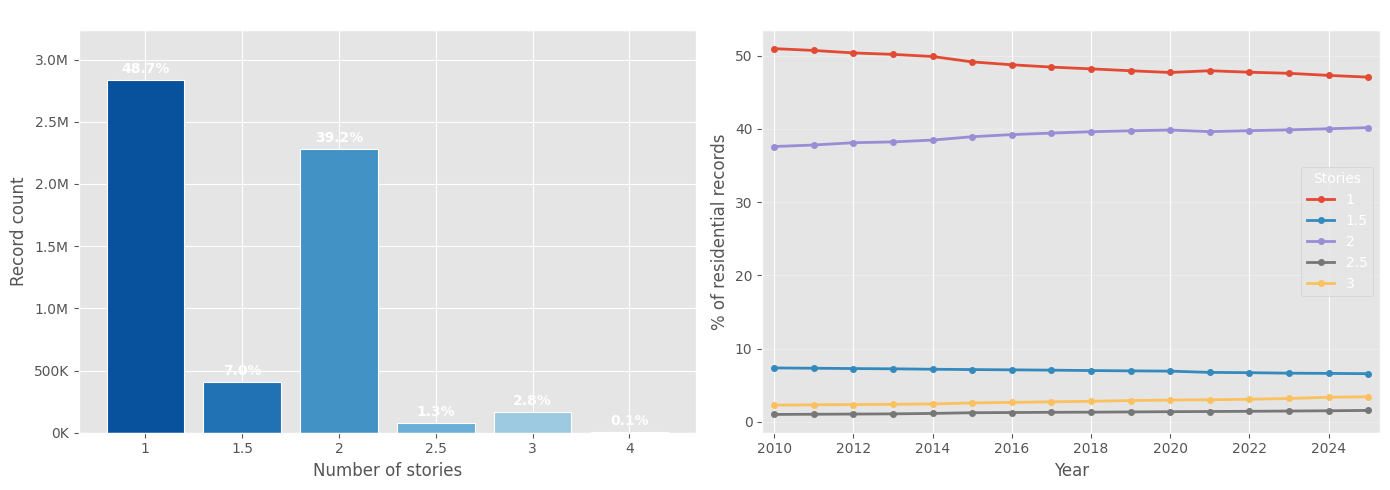

Residential records with bd_stories: 5,826,959  (rounded to nearest 0.5)

       count   pct
1    2838008  48.7
1.5   407415   7.0
2    2282181  39.2
2.5    75917   1.3
3     163202   2.8
4       5889   0.1


In [50]:
# ── stories distribution ──────────────────────────────────────────────────────
res = features[
    ~features['bd_is_condo'] &
    ~features['bd_is_common_element'] &
    features['bd_stories'].notna()
].copy()

# Round to nearest 0.5 to collapse data-entry noise (1.05, 1.1 → 1.0 etc.)
# while preserving meaningful half-story distinctions (1.5, 2.5)
res['bd_stories_r'] = (res['bd_stories'] * 2).round() / 2

# Keep only story values covering ≥ 0.1 % of residential records
total_res    = len(res)
story_counts = res['bd_stories_r'].value_counts().sort_index()
story_counts = story_counts[story_counts / total_res >= 0.001]

# Clean x-axis labels: "1" not "1.0", "1.5" stays "1.5"
x_labels = [str(int(v)) if v == int(v) else str(v) for v in story_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── left: bar chart ───────────────────────────────────────────────────────────
# Use explicit blue palette — avoid colormaps that approach white
palette = ['#08519c','#2171b5','#4292c6','#6baed6','#9ecae1','#c6dbef','#deebf7']
bar_colors = palette[:len(story_counts)]

bars = axes[0].bar(x_labels, story_counts.values,
                   color=bar_colors, edgecolor='white', linewidth=0.8)

axes[0].set_title('Stories distribution — residential parcels (all years)', fontsize=11)
axes[0].set_xlabel('Number of stories')
axes[0].set_ylabel('Record count')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K')
)
axes[0].set_ylim(0, story_counts.max() * 1.14)

for bar, count in zip(bars, story_counts.values):
    pct = count / total_res * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + story_counts.max() * 0.012,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# ── right: share by year (line) ───────────────────────────────────────────────
year_story = (
    res.groupby(['mod_iv_year', 'bd_stories_r'])
    .size()
    .unstack(fill_value=0)
)
year_story_pct = year_story.div(year_story.sum(axis=1), axis=0) * 100

# keep columns that ever exceed 1 % and rename to clean labels
major = year_story_pct.columns[year_story_pct.max() >= 1.0]
plot_df = year_story_pct[major].copy()
plot_df.columns = [str(int(v)) if v == int(v) else str(v) for v in plot_df.columns]

plot_df.plot(ax=axes[1], marker='o', markersize=4, linewidth=2)
axes[1].set_title('Stories share by year — residential', fontsize=11)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% of residential records')
axes[1].legend(title='Stories', loc='center right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xlim(plot_df.index.min() - 0.3, plot_df.index.max() + 0.3)

plt.tight_layout()
plt.show()

# ── summary table ──────────────────────────────────────────────────────────────
print(f"Residential records with bd_stories: {total_res:,}  (rounded to nearest 0.5)\n")
tbl = story_counts.rename('count').to_frame().assign(
    pct=lambda d: (d['count'] / total_res * 100).round(1)
)
tbl.index = x_labels
print(tbl.to_string())

In [51]:
import os

BD_COLS = ['bd_stories', 'bd_material', 'bd_style',
           'bd_garage_stalls', 'bd_garage_type',
           'bd_is_condo', 'bd_is_common_element', 'bd_unit_floor',
           'bd_is_model_plan']

# ── step 1: save thin temp parquet ────────────────────────────────────────────
TEMP    = 'data/building_desc_features.parquet'
OUT_TMP = 'data/parcels_shore_new.parquet'

features[['gis_pin', 'mod_iv_year'] + BD_COLS].to_parquet(TEMP, index=False)
print(f"Saved temp: {TEMP}  ({os.path.getsize(TEMP)/1e6:.0f} MB)")

# ── step 2: DuckDB join → write new file ─────────────────────────────────────
# If bd_* columns already exist in parcels_shore.parquet (re-run), exclude them
# so we don't produce duplicate column names.
existing_bd = duckdb.sql(f"""
    SELECT column_name
    FROM (DESCRIBE SELECT * FROM read_parquet('data/parcels_shore.parquet'))
    WHERE column_name LIKE 'bd_%'
""").df()['column_name'].tolist()

exclude_clause = f"EXCLUDE ({', '.join(existing_bd)})" if existing_bd else ""

bd_select = ', '.join(f'b.{c}' for c in BD_COLS)
duckdb.sql(f"""
    COPY (
        SELECT p.* {exclude_clause},
               {bd_select}
        FROM   read_parquet('data/parcels_shore.parquet') AS p
        LEFT JOIN read_parquet('{TEMP}') AS b
               ON p.gis_pin = b.gis_pin AND p.mod_iv_year = b.mod_iv_year
    ) TO '{OUT_TMP}' (FORMAT PARQUET)
""")
print(f"Written: {OUT_TMP}  ({os.path.getsize(OUT_TMP)/1e9:.2f} GB)")

# ── step 3: atomic swap + cleanup ────────────────────────────────────────────
os.replace(OUT_TMP, 'data/parcels_shore.parquet')
os.remove(TEMP)
print("parcels_shore.parquet updated. Temp files removed.")

Saved temp: data/building_desc_features.parquet  (42 MB)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Written: data/parcels_shore_new.parquet  (2.74 GB)
parcels_shore.parquet updated. Temp files removed.
